# JaxFEM – Kragarm (Lineare Elastizität)

Kragarm: **L = 10 m**, Querschnitt **b = h = 0,5 m**, Einzellast **F = 10 kN** (vertikal nach unten, an der freien Seite).

Analytische Lösung (Euler-Bernoulli): $w_{max} = \frac{F L^3}{3 E I}$

In [1]:
import jax
import jax.numpy as np
import numpy as onp
import matplotlib.pyplot as plt

from jax_fem.problem import Problem
from jax_fem.solver import solver
from jax_fem.generate_mesh import get_meshio_cell_type, Mesh, rectangle_mesh

print("JAX-Version:", jax.__version__)

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



[04-20 02:39:39][INFO] jax_fem: pyamgx not installed. AMGX solver disabled.


JAX-Version: 0.6.2


## 1. Materialparameter & Schwache Form

Einheiten: **kN** und **m** → E in kN/m².

Stahl: E = 210 000 kN/m², ν = 0,3.  
Flächenlast rechte Kante: t = F / h = 10 kN / 0,5 m = 20 kN/m².

**Vorzeichenkonvention JaxFEM:**  gibt eine Traktionsgröße zurück, bei der ein positiver y-Wert eine Kraft nach **unten** bewirkt (Kraft = −surface_map in die Systemmatrix).

In [2]:
# Geometrie [m]
Lx = 10.0   # Länge
Ly = 5.0    # Höhe des Querschnitts

# Materialparameter  (Einheiten: kN, m)
E  = 210_000.0  # kN/m²  (Stahl)
nu = 0.3
mu     = E / (2.0 * (1.0 + nu))
lmbda  = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))

# Flächenlast an der rechten Kante [kN/m²]
# Konvention JaxFEM: surface_map gibt "Traction" zurück, positives t_y = Kraft nach UNTEN
F_total = 10.0          # kN
t_y     = F_total / Ly  # kN/m²  (positiv = nach unten in JaxFEM)


class LinearElasticity2D(Problem):
    def get_tensor_map(self):
        def stress(u_grad):
            epsilon = 0.5 * (u_grad + u_grad.T)
            sigma = lmbda * np.trace(epsilon) * np.eye(self.dim) + 2.0 * mu * epsilon
            return sigma
        return stress

    def get_surface_maps(self):
        # positives t_y → Kraft in -y-Richtung (nach unten)
        def surface_map(u, x):
            return np.array([0.0, t_y])
        return [surface_map]

## 2. Netz erzeugen

2-D Scheibe mit QUAD4-Elementen:

In [3]:
ele_type  = "QUAD4"
cell_type = get_meshio_cell_type(ele_type)

meshio_mesh = rectangle_mesh(Nx=100, Ny=100, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
print("Knoten:", len(meshio_mesh.points), "  Elemente:", len(meshio_mesh.cells_dict[cell_type]))

Knoten: 10201   Elemente: 10000


## 3. Randbedingungen

### 3.1 Dirichlet-Randbedingungen (Einspannung)

**Position:** Linke Seite des Trägers (`x = 0`)  
**Art:** Punktweise Vorgabe von Verschiebungen an allen Knoten der linken Kante.  
**Werte:** `u_x = 0` und `u_y = 0` (vollständige Einspannung, keine Verschiebung und keine Verdrehung).

| Lastfall | Position | Typ | Beschreibung |
|---|---|---|---|
| Einspannung | Linke Kante, alle Knoten (Linie bei x = 0) | Dirichlet | Alle Freiheitsgrade gesperrt: u_x = u_y = 0. Entspricht einer starren Wand, an der der Kragarm befestigt ist. |

Implementierung in JaxFEM über `dirichlet_bc_info`: Für jede Komponente (0 = u_x, 1 = u_y) wird eine Ortsfunktion (`left`) und eine Wertefunktion (`zero`) übergeben.

---

### 3.2 Neumann-Randbedingungen (aufgeprägte Kräfte)

**Position:** Rechte Seite des Trägers (`x = Lx`)  
**Art:** Flächenlast (Traktionsvektor) auf der freien Kante – entspricht einer über die Höhe gleichmäßig verteilten Querkraft.

| Lastfall | Position | Typ | Beschreibung |
|---|---|---|---|
| Querkraft | Rechte Kante (Linie bei x = Lx) | Neumann | Gleichmäßige Flächenlast t_y = F / Ly in [kN/m²], die senkrecht zur Kante nach **unten** wirkt. Keine Normalkraft (t_x = 0). |

**Vorzeichenkonvention JaxFEM:** `surface_map` gibt einen Traktionsvektor zurück, bei dem ein **positiver** y-Wert eine Kraft in **−y-Richtung** (nach unten) bewirkt, da JaxFEM den Vektor intern mit dem negativen Vorzeichen in die Steifigkeitsmatrix einbaut.

Implementierung über `location_fns = [right]` und `get_surface_maps()` in der Problem-Klasse.

In [4]:
def left(point):
    return np.isclose(point[0], 0.0, atol=1e-5)

def right(point):
    return np.isclose(point[0], Lx, atol=1e-5)

def zero(point):
    return 0.0

# Beide Verschiebungskomponenten an der linken Seite fixieren
dirichlet_bc_info = [[left, left], [0, 1], [zero, zero]]

# Neumann-Rand (rechte Seite)
location_fns = [right]

## 4. Lösen

Der JAX-eigene CG-Solver ist bei Biegeproblemen schlecht konditioniert.  
Wir verwenden daher den direkten **umfpack**-Löser von scipy.

In [5]:
problem = LinearElasticity2D(
    mesh=mesh,
    vec=2,
    dim=2,
    ele_type=ele_type,
    dirichlet_bc_info=dirichlet_bc_info,
    location_fns=location_fns,
)
sol = solver(problem, solver_options={"umfpack_solver": {}})
print("Lösung berechnet. Shape:", sol[0].shape)

[04-20 02:39:39][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[04-20 02:39:39][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[04-20 02:39:39][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)
[04-20 02:39:39][DEBUG] jax_fem: Done pre-computations, took 0.5084202289581299 [s]
[04-20 02:39:39][INFO] jax_fem: Solving a problem with 10000 cells, 10201x2 = 20402 dofs.
[04-20 02:39:39][INFO] jax_fem: Element type is QUAD4, using 4 quad points per element.
[04-20 02:39:40][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[04-20 02:39:40][DEBUG] jax_fem: Start timing
[04-20 02:39:40][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[04-20 02:39:40][DEBUG] jax_fem: Function split_and_compute_cell took 0.0699 seconds
[04-20 02:39:41][DEBUG] jax_fem: Creating sparse matrix with scipy...
[04-20 02:39:41][DEBUG] jax_fem: Before, l_2 res = 0.99749686716301, relative l_2

Lösung berechnet. Shape: (10201, 2)


## 5. Ergebnis & Vergleich mit analytischer Lösung

### 5.1 Verschiebungen & Vergleich Euler-Bernoulli
### 5.2 Spannungen (σ_xx, σ_yy, τ_xy, von-Mises)
### 5.3 Dehnungen (ε_xx, ε_yy, γ_xy)
### 5.4 Hauptspannungen & Trajektorien

FEM  w_max = -1.67 mm
Ana. w_max = -1.52 mm  (Euler-Bernoulli)
Abweichung: 9.6 %


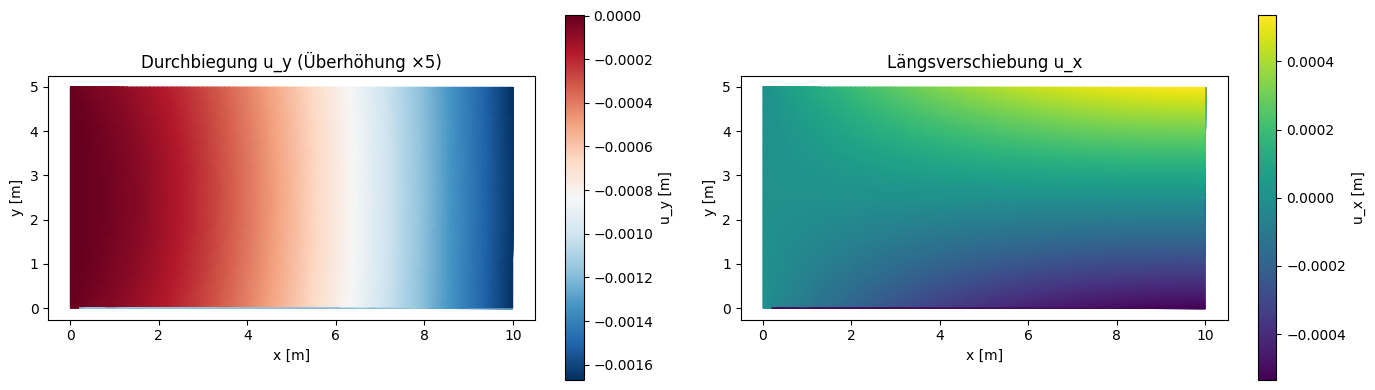

In [6]:
points = meshio_mesh.points
ux = sol[0][:, 0]
uy = sol[0][:, 1]

# Maximale Durchbiegung (FEM)
w_fem = float(np.min(uy))

# Analytische Lösung (Euler-Bernoulli, 2-D: I = b*h³/12 mit b=1 m Tiefe)
I = 1.0 * Ly**3 / 12.0
w_ana = -F_total * Lx**3 / (3.0 * E * I)
print(f"FEM  w_max = {w_fem*1000:.2f} mm")
print(f"Ana. w_max = {w_ana*1000:.2f} mm  (Euler-Bernoulli)")
print(f"Abweichung: {abs(w_fem - w_ana) / abs(w_ana) * 100:.1f} %")

# Verformte Geometrie (überhöht)
scale = 5.0
x_def = points[:, 0] + scale * onp.array(ux)
y_def = points[:, 1] + scale * onp.array(uy)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sc0 = axes[0].tripcolor(x_def, y_def, onp.array(uy), shading="gouraud", cmap="RdBu_r")
plt.colorbar(sc0, ax=axes[0], label="u_y [m]")
axes[0].set_title(f"Durchbiegung u_y (Überhöhung ×{scale:.0f})")
axes[0].set_xlabel("x [m]"); axes[0].set_ylabel("y [m]")
axes[0].set_aspect("equal")

sc1 = axes[1].tripcolor(x_def, y_def, onp.array(ux), shading="gouraud", cmap="viridis")
plt.colorbar(sc1, ax=axes[1], label="u_x [m]")
axes[1].set_title("Längsverschiebung u_x")
axes[1].set_xlabel("x [m]"); axes[1].set_ylabel("y [m]")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

In [7]:
### 5.2 Spannungen & Dehnungen – Berechnung an Gauss-Punkten + Extrapolation auf Knoten

import jax
from scipy.spatial import cKDTree

def compute_stress_strain_at_nodes(problem, sol_array):
    """
    Berechnet Spannungs- und Dehnungstensoren an jedem Knoten via
    Gauss-Punkt-Berechnung + einfacher Nearest-Neighbor-Extrapolation.
    Gibt zurück: sigma (N,3) = [sxx, syy, sxy], eps (N,3) = [exx, eyy, exy]
    """
    fe = problem.fes[0]
    u_nodes = sol_array  # (N_nodes, 2)

    # Alle Gauss-Punkte und physikalische Koordinaten
    # fe.shape_grads: (num_cells, num_quads, num_nodes_per_cell, dim)
    # fe.JxW: (num_cells, num_quads)
    cells = meshio_mesh.cells_dict[get_meshio_cell_type(ele_type)]  # (num_cells, 4)

    all_gp_coords = []
    all_sigma = []
    all_eps   = []

    for c_idx, cell in enumerate(cells):
        x_cell = points[cell]  # (4, 2) Knotenkoordinaten des Elements
        u_cell = onp.array(u_nodes[cell])  # (4, 2)

        # Gauss-Punkte im Referenzelement (2×2 für QUAD4)
        gauss_pts = onp.array([-1/onp.sqrt(3), 1/onp.sqrt(3)])
        gp_pairs  = [(xi, eta) for xi in gauss_pts for eta in gauss_pts]

        for (xi, eta) in gp_pairs:
            # Ansatzfunktionen und ihre Ableitungen im Referenzelement
            N  = onp.array([
                0.25*(1-xi)*(1-eta),
                0.25*(1+xi)*(1-eta),
                0.25*(1+xi)*(1+eta),
                0.25*(1-xi)*(1+eta),
            ])
            dN_dxi = onp.array([
                [-(1-eta), -(1-xi)],
                [ (1-eta), -(1+xi)],
                [ (1+eta),  (1+xi)],
                [-(1+eta),  (1-xi)],
            ]) * 0.25  # (4, 2): Spalten = ∂N/∂ξ, ∂N/∂η

            # Jacobi-Matrix J = dN_dxi.T @ x_cell  → (2,2)
            J  = dN_dxi.T @ x_cell
            Jinv = onp.linalg.inv(J)

            # Ableitungen im physikalischen Raum  (4, 2)
            dN_dx = dN_dxi @ Jinv.T

            # Physikalische Koordinaten des Gauss-Punkts
            x_gp = N @ x_cell  # (2,)

            # Verschiebungsgradient ∇u  (2,2)
            grad_u = dN_dx.T @ u_cell  # (2,2)

            # Dehnungstensor (lineare Kinematik)
            eps_tensor = 0.5 * (grad_u + grad_u.T)
            exx = eps_tensor[0, 0]
            eyy = eps_tensor[1, 1]
            exy = eps_tensor[0, 1]

            # Spannungstensor (Hooke, ebener Spannungszustand angenommen)
            sxx = (lmbda + 2*mu) * exx + lmbda * eyy
            syy = lmbda * exx + (lmbda + 2*mu) * eyy
            sxy = 2 * mu * exy

            all_gp_coords.append(x_gp)
            all_sigma.append([sxx, syy, sxy])
            all_eps.append([exx, eyy, exy])

    all_gp_coords = onp.array(all_gp_coords)
    all_sigma     = onp.array(all_sigma)
    all_eps       = onp.array(all_eps)

    # Nearest-Neighbor-Extrapolation: jedem Knoten den nächsten Gauss-Punkt zuweisen
    tree = cKDTree(all_gp_coords)
    _, idx = tree.query(points[:, :2])

    sigma_nodes = all_sigma[idx]   # (N_nodes, 3)
    eps_nodes   = all_eps[idx]     # (N_nodes, 3)

    return sigma_nodes, eps_nodes

sigma_nodes, eps_nodes = compute_stress_strain_at_nodes(problem, onp.array(sol[0]))

sxx = sigma_nodes[:, 0]
syy = sigma_nodes[:, 1]
sxy = sigma_nodes[:, 2]

exx = eps_nodes[:, 0]
eyy = eps_nodes[:, 1]
exy = eps_nodes[:, 2]

# Von-Mises-Vergleichsspannung (2D, ebener Spannungszustand)
s_vm = onp.sqrt(sxx**2 - sxx*syy + syy**2 + 3*sxy**2)

print(f"σ_xx: min={sxx.min():.2f}  max={sxx.max():.2f}  kN/m²")
print(f"σ_yy: min={syy.min():.2f}  max={syy.max():.2f}  kN/m²")
print(f"τ_xy: min={sxy.min():.2f}  max={sxy.max():.2f}  kN/m²")
print(f"von Mises σ_v: max={s_vm.max():.2f}  kN/m²")

σ_xx: min=-44.23  max=44.23  kN/m²
σ_yy: min=-15.72  max=15.72  kN/m²
τ_xy: min=-10.19  max=0.05  kN/m²
von Mises σ_v: max=42.66  kN/m²


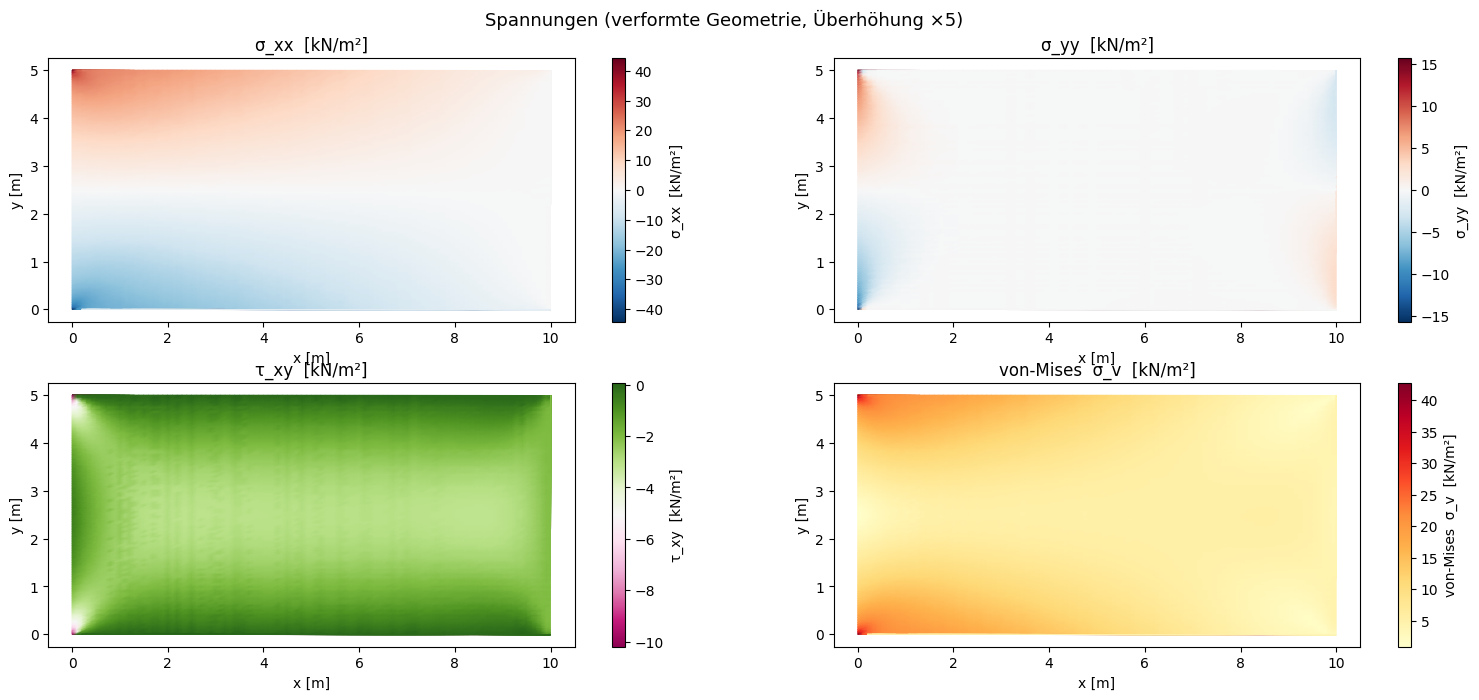

In [8]:
### Spannungs-Plots (σ_xx, σ_yy, τ_xy, von Mises)

fig, axes = plt.subplots(2, 2, figsize=(16, 7))
axes = axes.flatten()

plots = [
    (sxx, "σ_xx  [kN/m²]", "RdBu_r"),
    (syy, "σ_yy  [kN/m²]", "RdBu_r"),
    (sxy, "τ_xy  [kN/m²]", "PiYG"),
    (s_vm, "von-Mises  σ_v  [kN/m²]", "YlOrRd"),
]

for ax, (data, label, cmap) in zip(axes, plots):
    sc = ax.tripcolor(x_def, y_def, onp.array(data), shading="gouraud", cmap=cmap)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_title(label)
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

plt.suptitle("Spannungen (verformte Geometrie, Überhöhung ×5)", fontsize=13)
plt.tight_layout()
plt.show()

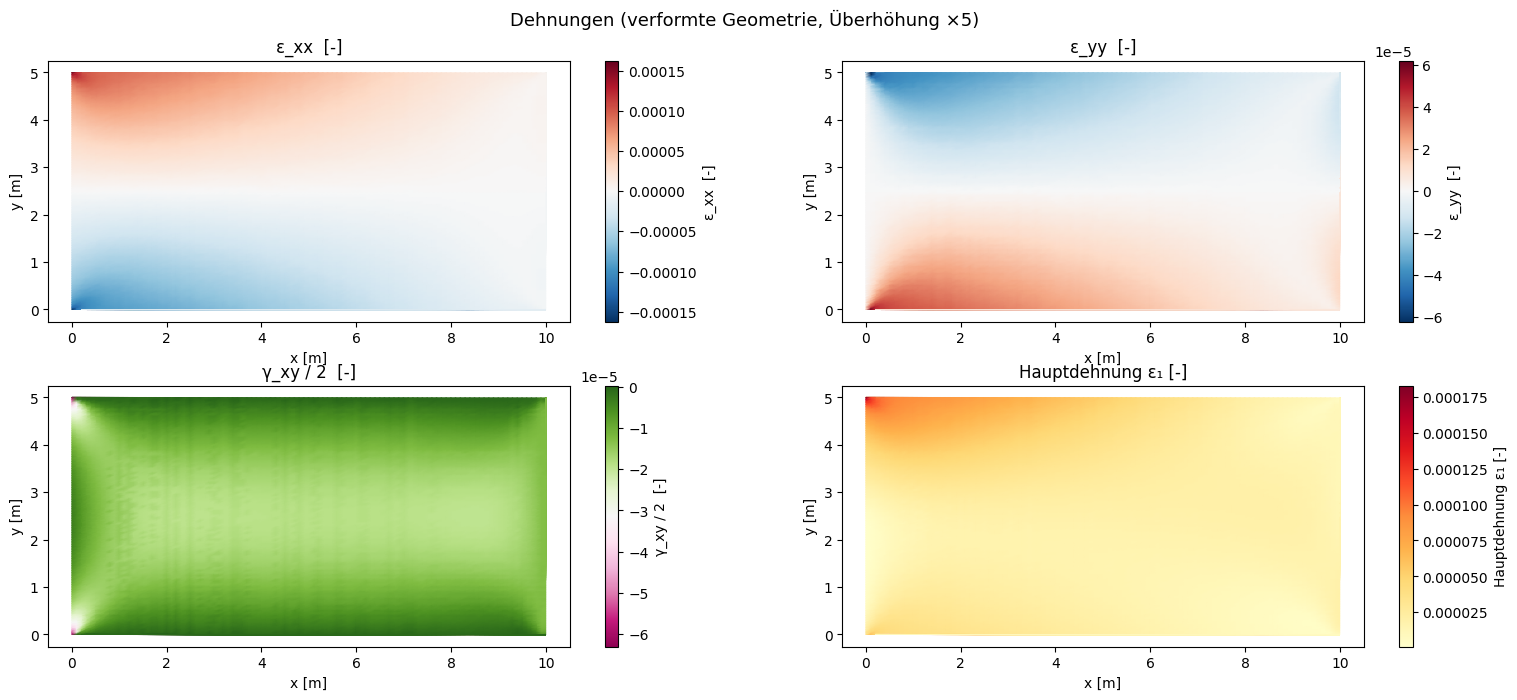

In [9]:
### 5.3 Dehnungs-Plots (ε_xx, ε_yy, γ_xy, Hauptdehnung ε₁)

# Hauptdehnungen (2D)
eps1 = 0.5*(exx + eyy) + onp.sqrt((0.5*(exx - eyy))**2 + exy**2)
eps2 = 0.5*(exx + eyy) - onp.sqrt((0.5*(exx - eyy))**2 + exy**2)

fig, axes = plt.subplots(2, 2, figsize=(16, 7))
axes = axes.flatten()

plots_eps = [
    (exx,  "ε_xx  [-]",       "RdBu_r"),
    (eyy,  "ε_yy  [-]",       "RdBu_r"),
    (exy,  "γ_xy / 2  [-]",   "PiYG"),
    (eps1, "Hauptdehnung ε₁ [-]", "YlOrRd"),
]

for ax, (data, label, cmap) in zip(axes, plots_eps):
    sc = ax.tripcolor(x_def, y_def, onp.array(data), shading="gouraud", cmap=cmap)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_title(label)
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

plt.suptitle("Dehnungen (verformte Geometrie, Überhöhung ×5)", fontsize=13)
plt.tight_layout()
plt.show()

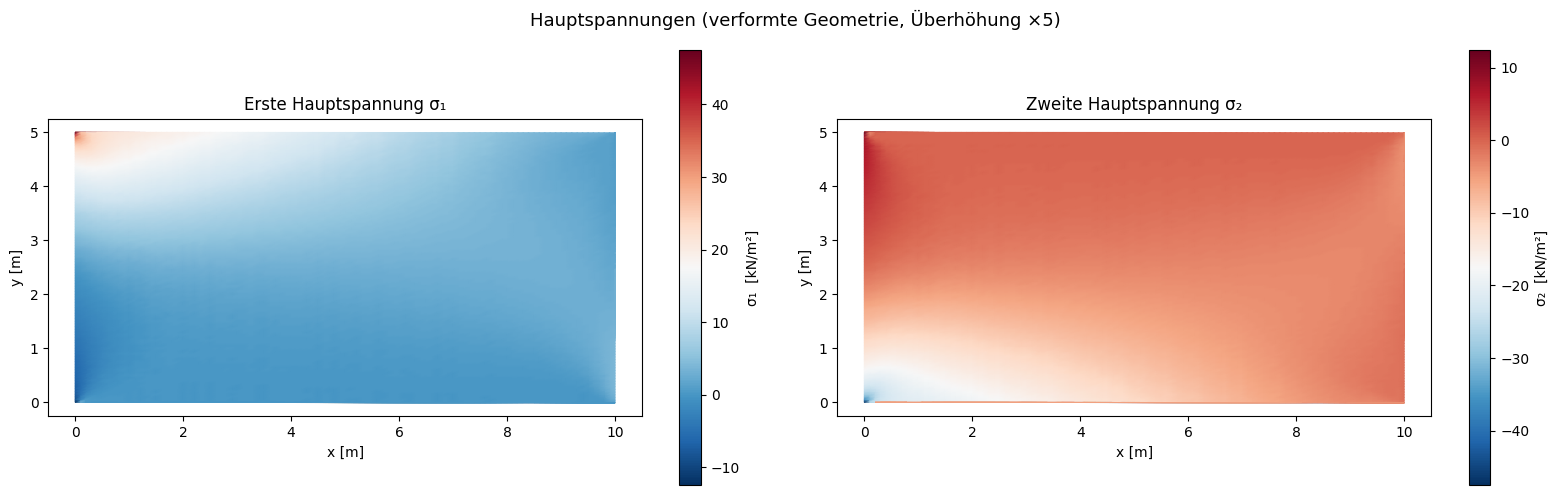

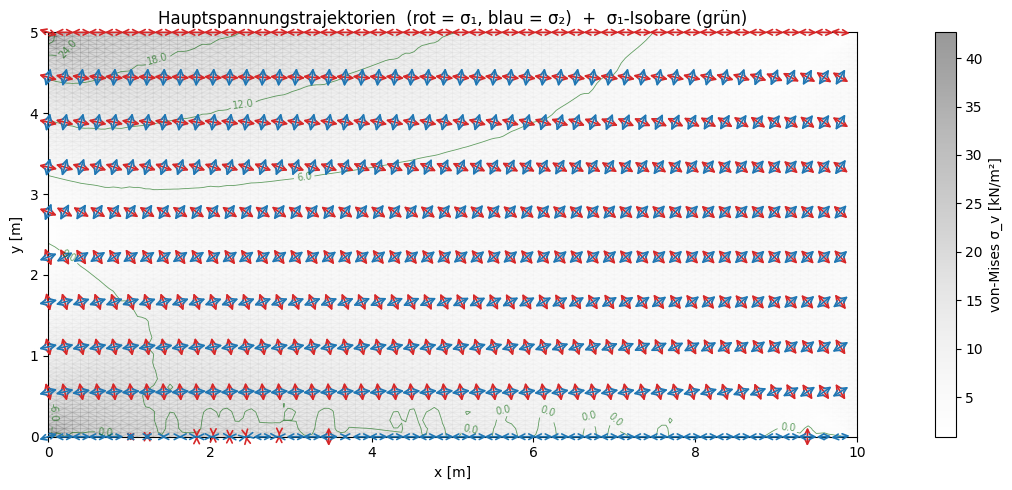

In [10]:
### 5.4 Hauptspannungen & Trajektorien

# Hauptspannungen und -richtungen an jedem Knoten
s1 = 0.5*(sxx + syy) + onp.sqrt((0.5*(sxx - syy))**2 + sxy**2)
s2 = 0.5*(sxx + syy) - onp.sqrt((0.5*(sxx - syy))**2 + sxy**2)

# Winkel der ersten Hauptspannungsrichtung
theta = 0.5 * onp.arctan2(2*sxy, sxx - syy)  # Winkel in rad

# Einheitsvektoren der Hauptspannungsrichtungen
e1x = onp.cos(theta)
e1y = onp.sin(theta)
e2x = -onp.sin(theta)
e2y =  onp.cos(theta)

# ── Plot 1: Hauptspannungsbeträge als Farbplot ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sc_s1 = axes[0].tripcolor(x_def, y_def, s1, shading="gouraud", cmap="RdBu_r")
plt.colorbar(sc_s1, ax=axes[0], label="σ₁  [kN/m²]")
axes[0].set_title("Erste Hauptspannung σ₁")
axes[0].set_xlabel("x [m]"); axes[0].set_ylabel("y [m]")
axes[0].set_aspect("equal")

sc_s2 = axes[1].tripcolor(x_def, y_def, s2, shading="gouraud", cmap="RdBu_r")
plt.colorbar(sc_s2, ax=axes[1], label="σ₂  [kN/m²]")
axes[1].set_title("Zweite Hauptspannung σ₂")
axes[1].set_xlabel("x [m]"); axes[1].set_ylabel("y [m]")
axes[1].set_aspect("equal")

plt.suptitle("Hauptspannungen (verformte Geometrie, Überhöhung ×5)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Plot 2: Hauptspannungstrajektorien als Vektorfeld (Quiver) ────────────────
# Subsample: auf regulärem Gitter auswerten (Interpolation)
from scipy.interpolate import LinearNDInterpolator

# Interpolatoren für Vektorkomponenten
interp_e1x = LinearNDInterpolator(points[:, :2], e1x)
interp_e1y = LinearNDInterpolator(points[:, :2], e1y)
interp_e2x = LinearNDInterpolator(points[:, :2], e2x)
interp_e2y = LinearNDInterpolator(points[:, :2], e2y)
interp_vm  = LinearNDInterpolator(points[:, :2], s_vm)

nx_q, ny_q = 50, 10
xq = onp.linspace(0, Lx, nx_q)
yq = onp.linspace(0, Ly, ny_q)
Xq, Yq = onp.meshgrid(xq, yq)
pts_q = onp.column_stack([Xq.ravel(), Yq.ravel()])

E1x = interp_e1x(pts_q).reshape(ny_q, nx_q)
E1y = interp_e1y(pts_q).reshape(ny_q, nx_q)
E2x = interp_e2x(pts_q).reshape(ny_q, nx_q)
E2y = interp_e2y(pts_q).reshape(ny_q, nx_q)
VM  = interp_vm(pts_q).reshape(ny_q, nx_q)

# Interpolatoren für Hauptspannungen
interp_s1 = LinearNDInterpolator(points[:, :2], s1)
interp_s2 = LinearNDInterpolator(points[:, :2], s2)

S1_q = interp_s1(pts_q).reshape(ny_q, nx_q)
S2_q = interp_s2(pts_q).reshape(ny_q, nx_q)

# Vektorlänge skalieren mit Spannungswerten
max_s1 = onp.max(onp.abs(s1))
max_s2 = onp.max(onp.abs(s2))
arrow_base = 0.3  # m, Basislänge

fig, ax = plt.subplots(figsize=(16, 5))

# Hintergrund: von-Mises
sc = ax.tripcolor(points[:, 0], points[:, 1], s_vm, shading="gouraud",
                  cmap="Greys", alpha=0.4)
plt.colorbar(sc, ax=ax, label="von-Mises σ_v [kN/m²]")

# Hauptspannungstrajektorien: doppelköpfige Pfeile (Zug/Druck durch Farbe)
for i in range(ny_q):
    for j in range(nx_q):
        x0, y0 = Xq[i, j], Yq[i, j]
        dx1, dy1 = E1x[i, j], E1y[i, j]
        dx2, dy2 = E2x[i, j], E2y[i, j]
        vm_val = VM[i, j]
        if onp.isnan(dx1):
            continue
        # σ₁-Richtung: rot = Zug, blau = Druck (abhängig vom Vorzeichen)
        c1 = "tab:red"
        c2 = "tab:blue"
        hl = arrow_base * 0.5
        ax.annotate("", xy=(x0+dx1*hl, y0+dy1*hl), xytext=(x0-dx1*hl, y0-dy1*hl),
                    arrowprops=dict(arrowstyle="<->", color=c1, lw=1.2))
        ax.annotate("", xy=(x0+dx2*hl, y0+dy2*hl), xytext=(x0-dx2*hl, y0-dy2*hl),
                    arrowprops=dict(arrowstyle="<->", color=c2, lw=1.2))

# Konturlinien (Isobar)
try:
    xi_c = onp.linspace(points[:, 0].min(), points[:, 0].max(), 200)
    yi_c = onp.linspace(points[:, 1].min(), points[:, 1].max(), 50)
    Xi_c, Yi_c = onp.meshgrid(xi_c, yi_c)
    interp_s1 = LinearNDInterpolator(points[:, :2], s1)
    S1_c = interp_s1(onp.column_stack([Xi_c.ravel(), Yi_c.ravel()])).reshape(50, 200)
    cs = ax.contour(Xi_c, Yi_c, S1_c, levels=10, colors="darkgreen", linewidths=0.6, alpha=0.6)
    ax.clabel(cs, fmt="%.1f", fontsize=7)
except Exception:
    pass

ax.set_xlim(0, Lx); ax.set_ylim(0, Ly)
ax.set_aspect("equal")
ax.set_title("Hauptspannungstrajektorien  (rot = σ₁, blau = σ₂)  +  σ₁-Isobare (grün)")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
plt.tight_layout()
plt.show()

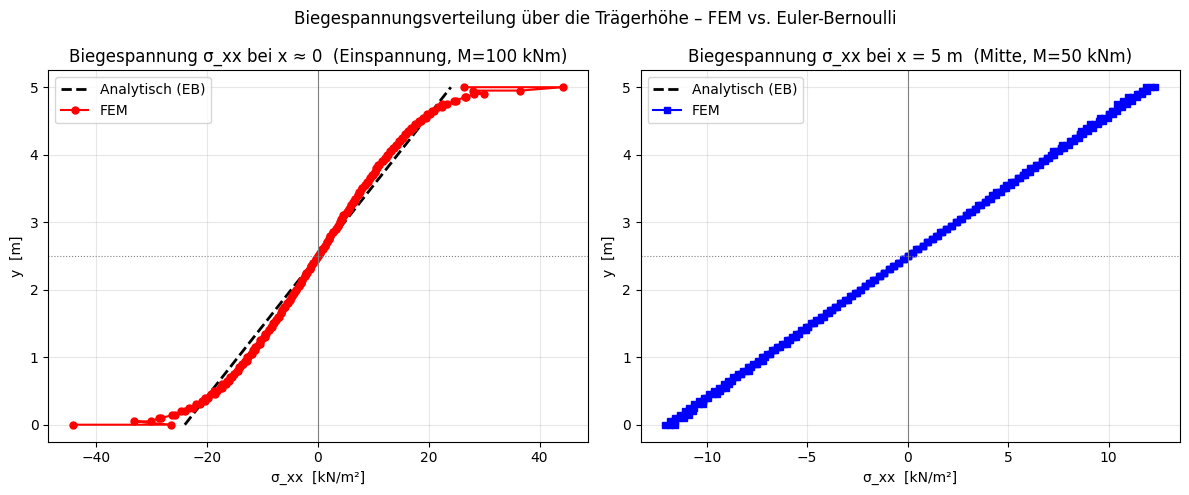

In [11]:
### 5.5 Querschnittsplot: σ_xx über die Trägerhöhe (Biegespannung)

# Analytische Biegespannung an der Einspannung (x=0): σ_xx = M·y / I
# M = F * Lx (Biegemoment an der Einspannung)
M_max = F_total * Lx  # kN·m
y_vals_ana = onp.linspace(0, Ly, 200)
y_center = Ly / 2.0
sigma_ana = M_max * (y_vals_ana - y_center) / I  # kN/m²

# FEM: Knoten nahe x=0 (linker Rand, innerste Querschnittslinie)
tol_x = Lx / 40 * 0.6   # etwas mehr als halbe Elementbreite
mask_left = (points[:, 0] < tol_x)
y_fem   = points[mask_left, 1]
sxx_fem = sxx[mask_left]
sort_idx = onp.argsort(y_fem)
y_fem_s   = y_fem[sort_idx]
sxx_fem_s = sxx_fem[sort_idx]

# Analytische Biegespannung in Trägermitte (x = Lx/2)
x_mid = Lx / 2
mask_mid = (onp.abs(points[:, 0] - x_mid) < Lx / 40 * 0.6)
y_mid_fem   = points[mask_mid, 1]
sxx_mid_fem = sxx[mask_mid]
sort_mid    = onp.argsort(y_mid_fem)
M_mid = F_total * (Lx - x_mid)
sigma_mid_ana = M_mid * (onp.linspace(0, Ly, 200) - y_center) / I

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linker Rand (Einspannung)
axes[0].plot(sigma_ana, y_vals_ana, "k--", lw=2, label="Analytisch (EB)")
axes[0].plot(sxx_fem_s, y_fem_s, "ro-", ms=5, label="FEM")
axes[0].axvline(0, color="gray", lw=0.8)
axes[0].axhline(y_center, color="gray", lw=0.8, linestyle=":")
axes[0].set_xlabel("σ_xx  [kN/m²]")
axes[0].set_ylabel("y  [m]")
axes[0].set_title(f"Biegespannung σ_xx bei x ≈ 0  (Einspannung, M={M_max:.0f} kNm)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Trägermitte
axes[1].plot(sigma_mid_ana, onp.linspace(0, Ly, 200), "k--", lw=2, label="Analytisch (EB)")
axes[1].plot(sxx_mid_fem[sort_mid], y_mid_fem[sort_mid], "bs-", ms=5, label="FEM")
axes[1].axvline(0, color="gray", lw=0.8)
axes[1].axhline(y_center, color="gray", lw=0.8, linestyle=":")
axes[1].set_xlabel("σ_xx  [kN/m²]")
axes[1].set_ylabel("y  [m]")
axes[1].set_title(f"Biegespannung σ_xx bei x = {x_mid:.0f} m  (Mitte, M={M_mid:.0f} kNm)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Biegespannungsverteilung über die Trägerhöhe – FEM vs. Euler-Bernoulli", fontsize=12)
plt.tight_layout()
plt.show()